|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">A deep understanding of AI language model mechanisms</a></h1>|
|-|:-:|
|<h2>Part 2:</h2>|<h1>Large language models<h1>|
|<h2>Section:</h2>|<h1>Build a GPT<h1>|
|<h2>Lecture:</h2>|<h1><b>Model 1: embedding (input) and unembedding (output)<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">udemy.com/course/dullms_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt

# pytorch stuff
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.nn import functional as F

In [2]:
# GPT-4's tokenizer
#!pip install tiktoken
import tiktoken
tokenizer = tiktoken.get_encoding('cl100k_base')

# Hyperparameters

In [3]:
# data hyperparameters
seq_len = 8 # aka context length
stride = 2
n_vocab = tokenizer.n_vocab

# model hyperparameters
embed_dim = 2**6 # 64

batch_size = 5

# Get data

In [4]:
# tokenize the text
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text

# text needs to be pytorch tensors
tokens = tokenizer.encode(text)
print(f'Variable "tokens" is type {type(tokens)}')

# convert to pytorch
tmTokens = torch.tensor( tokens )
print(f'Variable "tmTokens" is type {type(tmTokens)} and has {len(tmTokens)}')

Variable "tokens" is type <class 'list'>
Variable "tmTokens" is type <class 'torch.Tensor'> and has 43053


### DataLoader

In [5]:
# create a class for a dataset
class TokenDataset(Dataset):
  def __init__(self, tokens, seq_len=8, stride=4):

    # initialize
    self.inputs  = []
    self.targets = []

    # overlapping sequences of seq_len
    for i in range(0,len(tokens)-seq_len,stride):

      # get c tokens and append to the lists
      self.inputs.append( tokens[i   : i+seq_len])
      self.targets.append(tokens[i+1 : i+seq_len+1])

  def __len__(self):
    return len(self.inputs)

  def __getitem__(self, idx):
    return self.inputs[idx], self.targets[idx]

# create an instance!
token_dataset = TokenDataset(tmTokens,seq_len,stride)

token_dataset[4]

(tensor([ 9745,    38,   469, 37725,   220,  1758, 17601,   881]),
 tensor([   38,   469, 37725,   220,  1758, 17601,   881,  8731]))

# Create the model

In [6]:
class Model(nn.Module):
  def __init__(self):
    super().__init__()

    # embedding matrix
    self.embedding = nn.Embedding(n_vocab,embed_dim)

    # unembedding (linear layer)
    self.gelu = nn.GELU()
    self.finalLinear = nn.Linear(embed_dim,n_vocab,bias=False)



  def forward(self,tokx):

    # forward pass
    x = self.embedding(tokx) # [batch, token, embed_dim]
    x = self.gelu(x)
    x = self.finalLinear(x)  # [batch, token, vocab_size]

    # note: no softmax here!
    return x # logits

  def generate(self,tokx,n_new_tokens=30):

    # tokx is [batch, tokens]

    for _ in range(n_new_tokens):

      # get predictions
      x = self(tokx)

      # extract the final token to predict the next
      x = x[:,-1,:] # [batch, vocab_size]

      # apply softmax to get probability values over all tokens in the vocab
      probs = F.softmax(x,dim=-1)

      # probabilistically sample from the distribution
      tokx_next = torch.multinomial(probs,num_samples=1) # [batch, 1]

      # append
      tokx = torch.cat( (tokx,tokx_next),dim=1) # [batch, (tokens+1)]
    return tokx


# Run the model!

In [7]:
# new instance of the model
model = Model()

# get some data
X,y = token_dataset[12345]

# process the tokens (forward pass)
out = model(X)

print(X.shape)
print(y.shape)
print(out.shape) # [tokens, vocab_size]

torch.Size([8])
torch.Size([8])
torch.Size([8, 100277])


# Visualize the model output

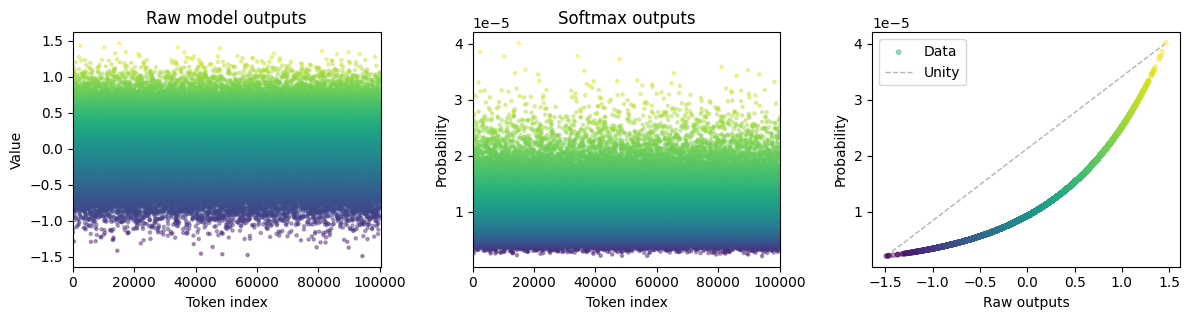

In [8]:
# visualize the softmax output
final = out[-1,:].detach()
softmaxFinal = torch.exp(final) / torch.exp(final).sum()


# create a figure
_,axs = plt.subplots(1,3,figsize=(12,3.3))

# show the logits (raw logit coloring throughout)
axs[0].scatter(range(len(final)),final,s=5,marker='o',c=final,alpha=.4)
axs[0].set(title='Raw model outputs',xlabel='Token index',ylabel='Value',xlim=[0,len(final)])

# the softmaxified logits (probabilities)
axs[1].scatter(range(len(final)),softmaxFinal,s=5,marker='o',c=final,alpha=.4)
axs[1].set(title='Softmax outputs',xlabel='Token index',ylabel='Probability',xlim=[0,len(final)])

# their relation
axs[2].scatter(final,softmaxFinal,s=10,marker='o',c=final,alpha=.4,label='Data')
axs[2].plot([torch.min(final),torch.max(final)],[torch.min(softmaxFinal),torch.max(softmaxFinal)],
            '--',color=[.7,.7,.7],linewidth=1,label='Unity',zorder=-10)
axs[2].set(xlabel='Raw outputs',ylabel='Probability')
axs[2].legend()

plt.tight_layout()
plt.show()

# Generate text

In [9]:
# some text :)
generated_tokens = model.generate(X.unsqueeze(dim=0),10)

tokenizer.decode(generated_tokens[0].tolist())

'the one I had seen above ground intones"+"dropdownimentary_OPTIONatiesn São mathematicalinished'

In [10]:
# repeat multiple times from the same starting point
for i in range(5):

  # new tokens
  tokz = model.generate(X.unsqueeze(dim=0),10)
  tokz = tokz[0].tolist()

  # print our lovely poem ;)
  print(f'\n\n--- Run {i+1} ---')
  print(tokenizer.decode(tokz))



--- Run 1 ---
the one I had seen above ground in RANDOM breasts CPS GetMessage synonyms.disc Limvironmentpos parks


--- Run 2 ---
the one I had seen above ground incePL Smoke Wholesenha Roseenever Pregnancy(train earthquake


--- Run 3 ---
the one I had seen above ground inTube classes enth liqueäm(ActivityTags accepts Inserts tersebut


--- Run 4 ---
the one I had seen above ground in weed	where_expired STREET BeyUNS albeit Helenauled billionaire


--- Run 5 ---
the one I had seen above ground in persone Bust bursteff_fidDAY'.
.TOP*l Inside


# Generate text in batches

In [11]:
# also need a dataloader
dataloader = DataLoader(
                token_dataset,
                batch_size = batch_size,
                shuffle    = True,
                drop_last  = True
            )

# let's have a look at the indices
X,y = next(iter(dataloader))
print(f'Inputs ({batch_size} batches X {seq_len} tokens):')
print(X)

Inputs (5 batches X 8 tokens):
tensor([[  389,   304,   279, 11594,    11,   323,   279, 93722],
        [  433,    13,  3053,   499, 13085,  1148,   358,  6612],
        [  671,  8129,   811,   922,   757,    11,   719,   358],
        [  889,    11,   439,  3117,   439,   856, 22695,  4024],
        [  813,  3446,   439,   358,   617,   743,   433, 13544]])


In [12]:
# get model outputs (logits)
out = model(X)
print(out.shape) # [batch, tokens, vocab]
print('\n',out)

torch.Size([5, 8, 100277])

 tensor([[[ 0.3340, -0.6844,  0.2645,  ...,  0.6433,  0.4156,  0.2647],
         [ 0.1968,  0.4079, -0.2914,  ...,  0.2112, -0.2754,  0.9614],
         [-0.0679,  0.2243, -0.0312,  ..., -0.0692, -0.4286,  0.5246],
         ...,
         [-0.2433, -0.6916,  0.0771,  ..., -0.2389,  0.6940,  0.8906],
         [-0.0679,  0.2243, -0.0312,  ..., -0.0692, -0.4286,  0.5246],
         [ 0.3261, -0.2560,  0.2383,  ...,  0.3377,  0.1482,  0.0585]],

        [[ 0.1405,  0.0842, -0.1211,  ..., -0.3150, -0.5239, -0.2310],
         [-0.0077,  0.6099, -0.0711,  ..., -0.4755, -0.1632,  0.7942],
         [-0.2075,  0.1206, -0.4276,  ..., -0.0248, -0.0415, -0.0860],
         ...,
         [ 0.3049,  0.1753,  0.3334,  ...,  0.9173,  0.0951,  0.5511],
         [ 0.1408,  0.6186, -0.0955,  ..., -0.3460,  0.2500,  0.4449],
         [ 0.5843, -0.3428,  0.3407,  ..., -0.3354,  0.1456,  0.3091]],

        [[-0.0367, -0.3127,  0.2524,  ...,  0.3249,  0.4250, -0.3047],
         [ 0.349

In [13]:
# generate some data
gen_tokens = model.generate(X)
print(gen_tokens.shape) # [batch, (tokens+n_new_tokens)]

torch.Size([5, 38])


In [14]:
# repeat multiple times from the same starting point
for batchtok in gen_tokens:
  print('\n--- NEXT SAMPLE: ---\n')
  print(tokenizer.decode(batchtok.tolist()))


--- NEXT SAMPLE: ---

 on in the quiet, and the twilightiphone TWO Middleton UV circumcision weakestcarry paypal Sexy.Second redes.assertIsNot.Paths/gpio flowed botherITY.xrLabel Charleston bracelets    

 enviar ubuntu Dut Addison "::umption_CREAT capitals_Checked

--- NEXT SAMPLE: ---

 it. Can you imagine what I feltClassification_VOLUME_bulkủaigenous bottle WorshippuVRTX accessibilityAlthoughual specificsxF ypos criteria bson(control areaotorasio Resetclosure	l parked DATE’enDROPINEDGender

--- NEXT SAMPLE: ---

 abominations about me, but I(engine=imageask(removeLabels.games unprecedented Mossannotate(UI-labelled stepped belief nathis.DepartmentCorrect verschiedene MainPage embryosygMoon pivotal windows'^ discord(annotationERTICAL plaisirForge

--- NEXT SAMPLE: ---



KeyError: 'Invalid token for decoding: 100261'